# Guía práctica 1

## Ejercicio 8 (a)


In [ ]:
from matplotlib.pyplot import (
    axvline,
    figure,
    grid,
    legend,
    plot,
    show,
    stem,
    title,
    xlabel,
    ylabel,
)
from numpy import (
    arange,
    arccos,
    clip,
    cos,
    linspace,
    log10,
    pi,
    sinc,
    where,
    zeros,
)

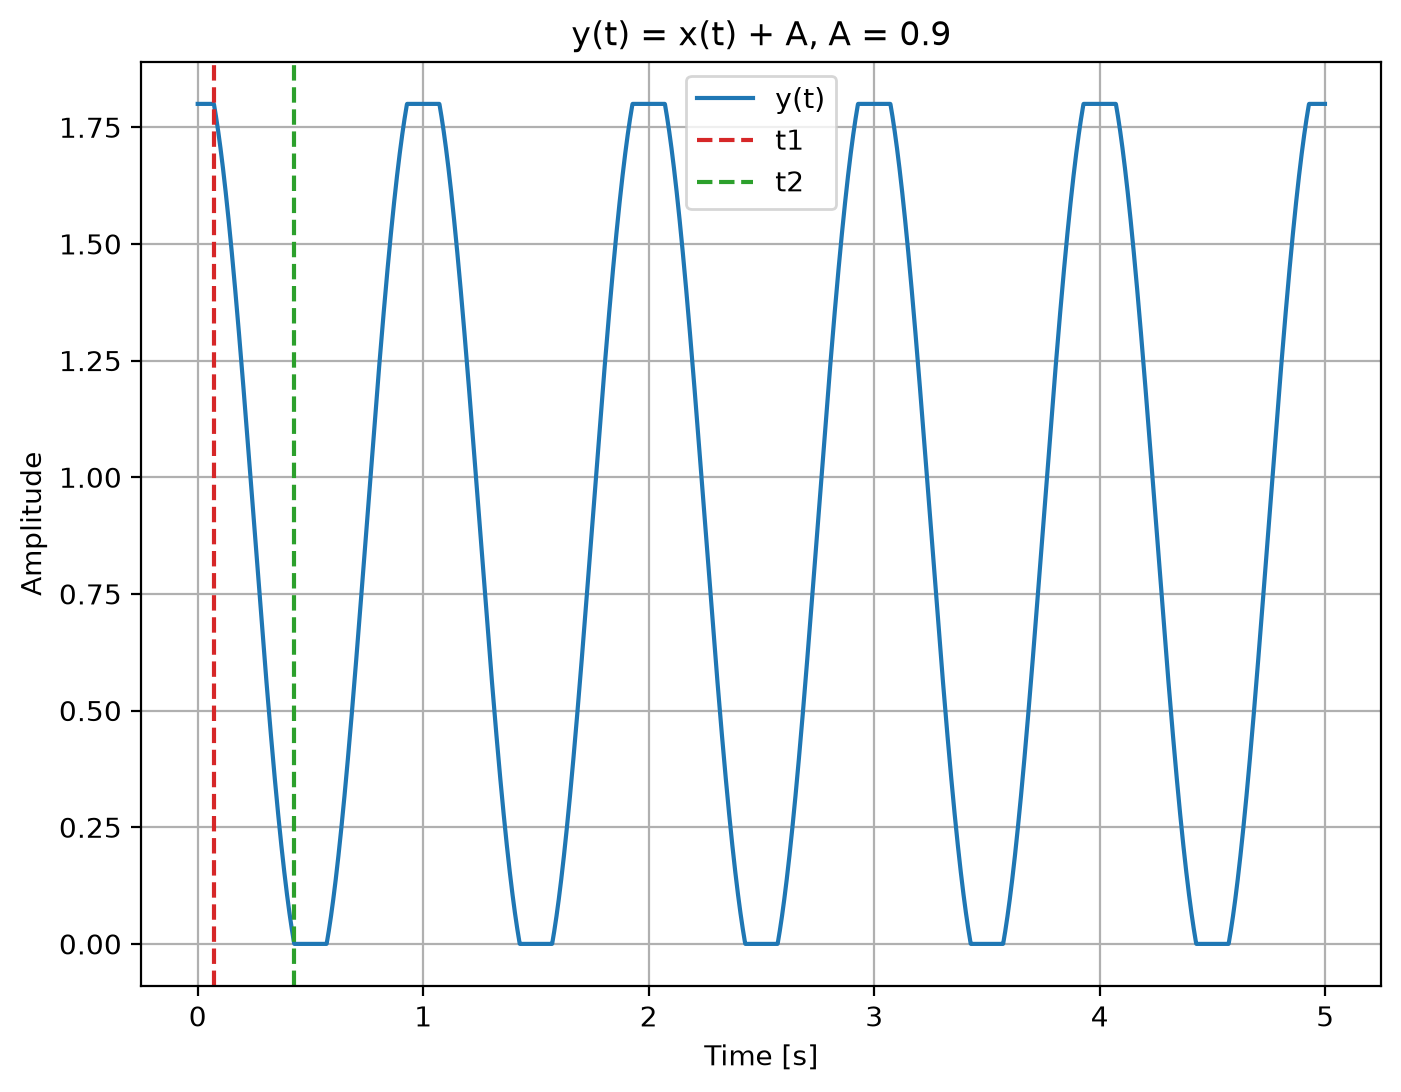

In [ ]:
sampling_freq_hz = 1e3
duration_s = 5
n_samples = int(sampling_freq_hz * duration_s)

t = arange(n_samples) / sampling_freq_hz

A = 0.9
x = clip(cos(2 * pi * t), -A, A)
y = x + A

t1 = arccos(A) / (2 * pi)
t2 = arccos(-A) / (2 * pi)

figure(1, figsize=(8, 6), dpi=200)
plot(t, y, label="y(t)")
axvline(t1, color="tab:red", linestyle="--", label="t1")
axvline(t2, color="tab:green", linestyle="--", label="t2")
xlabel("Time [s]")
ylabel("Amplitude")
title(f"y(t) = x(t) + A, A = {A}")
legend()
grid(True)
show()

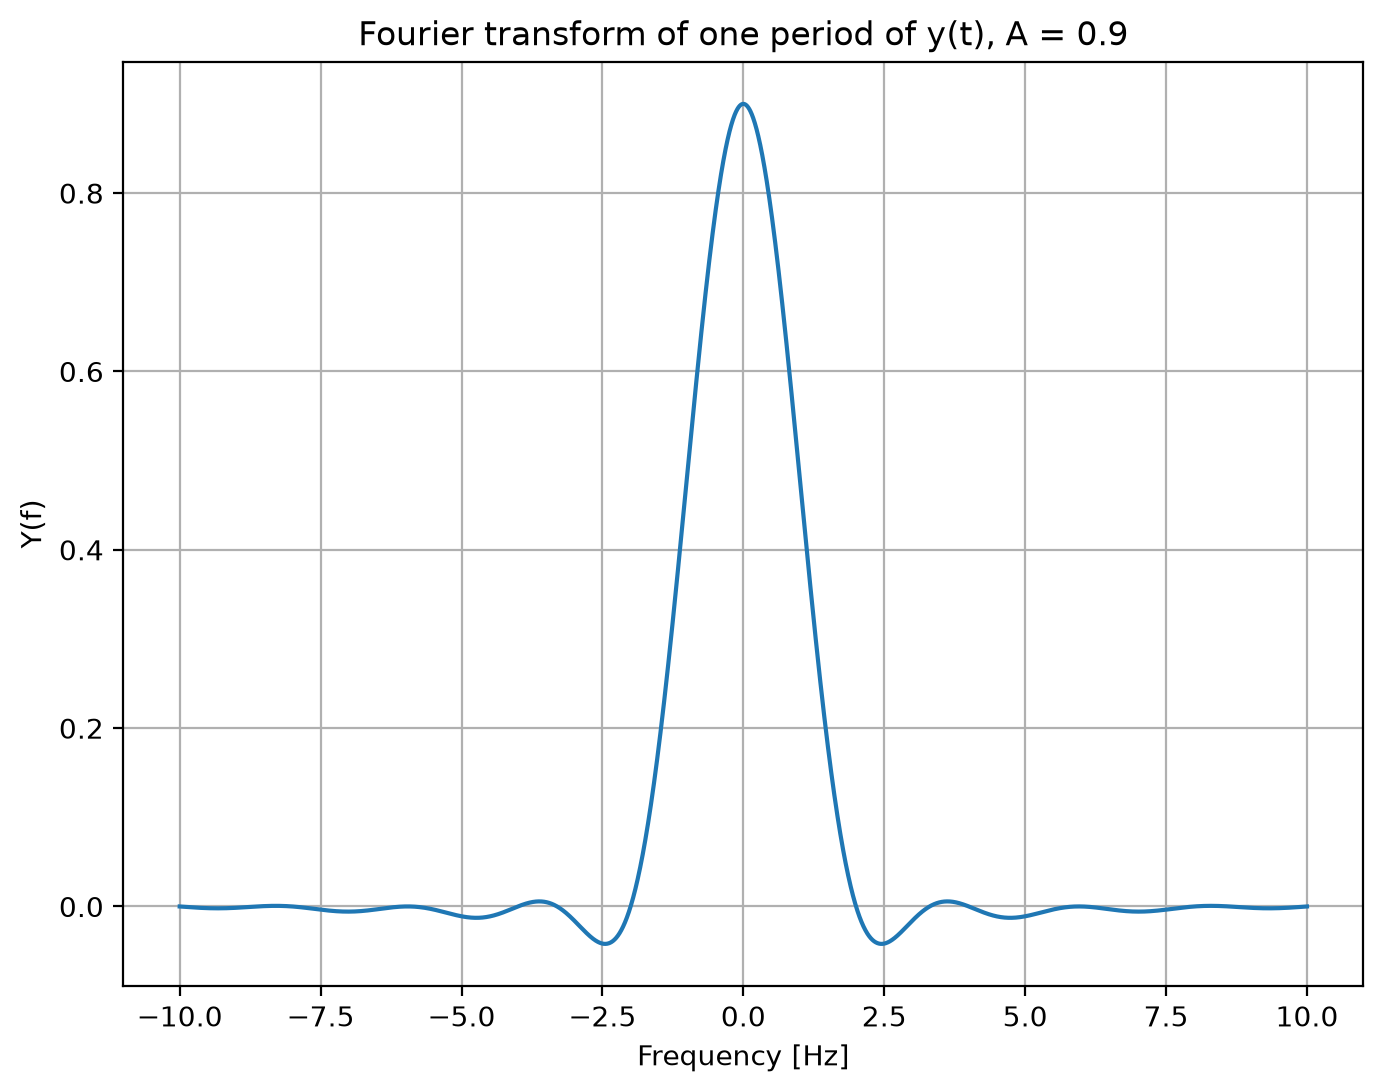

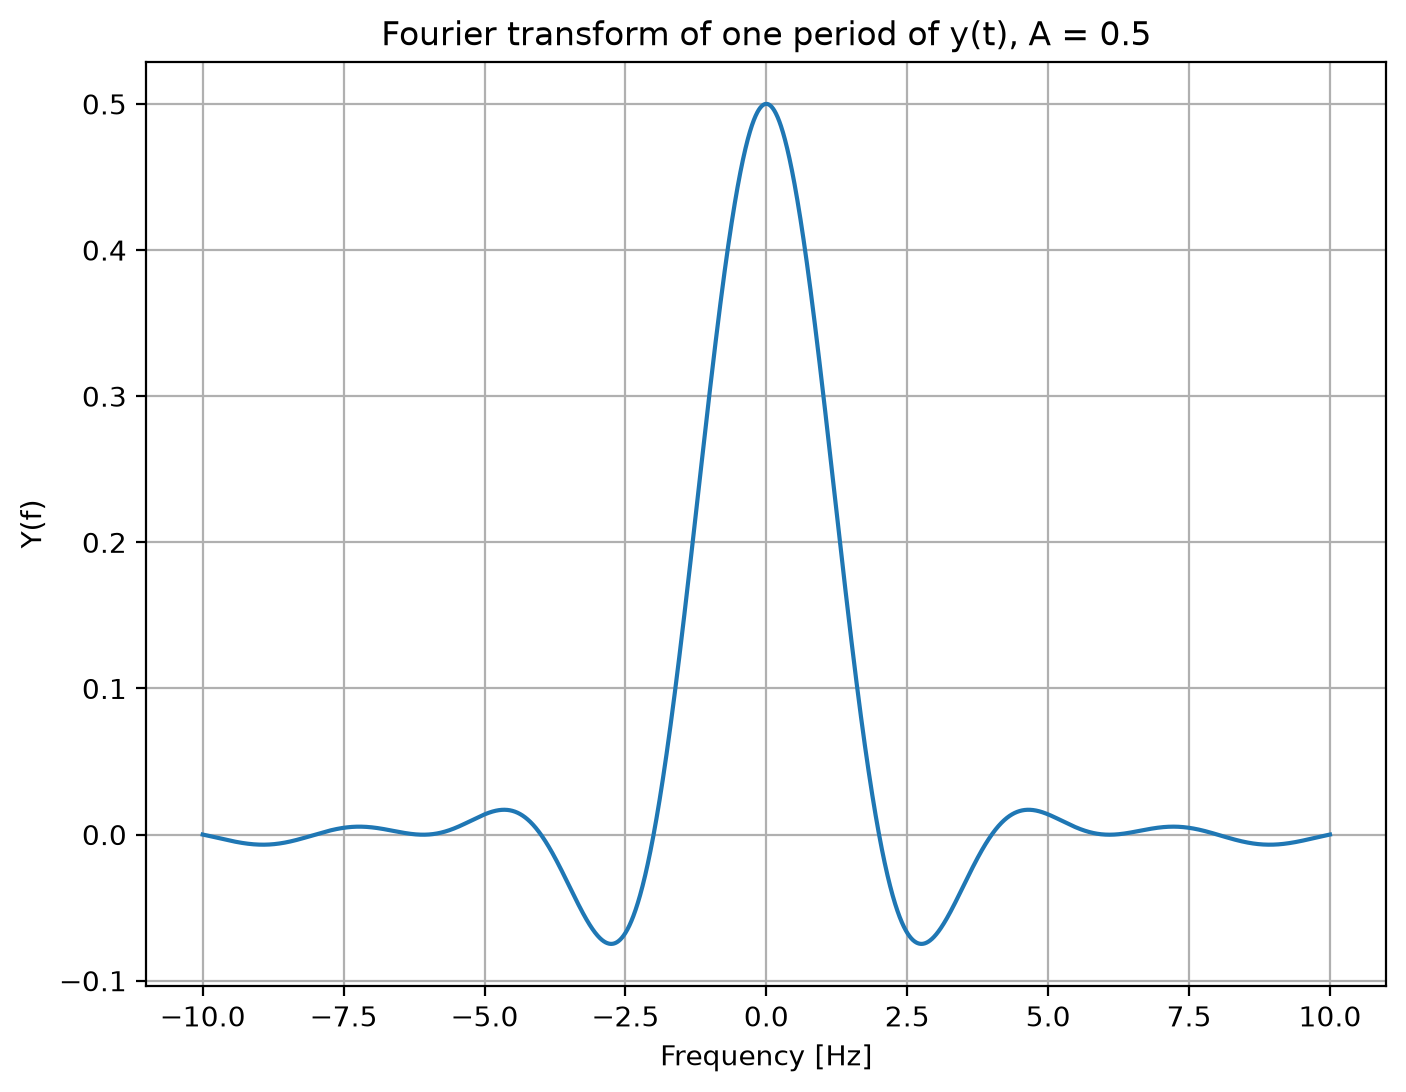

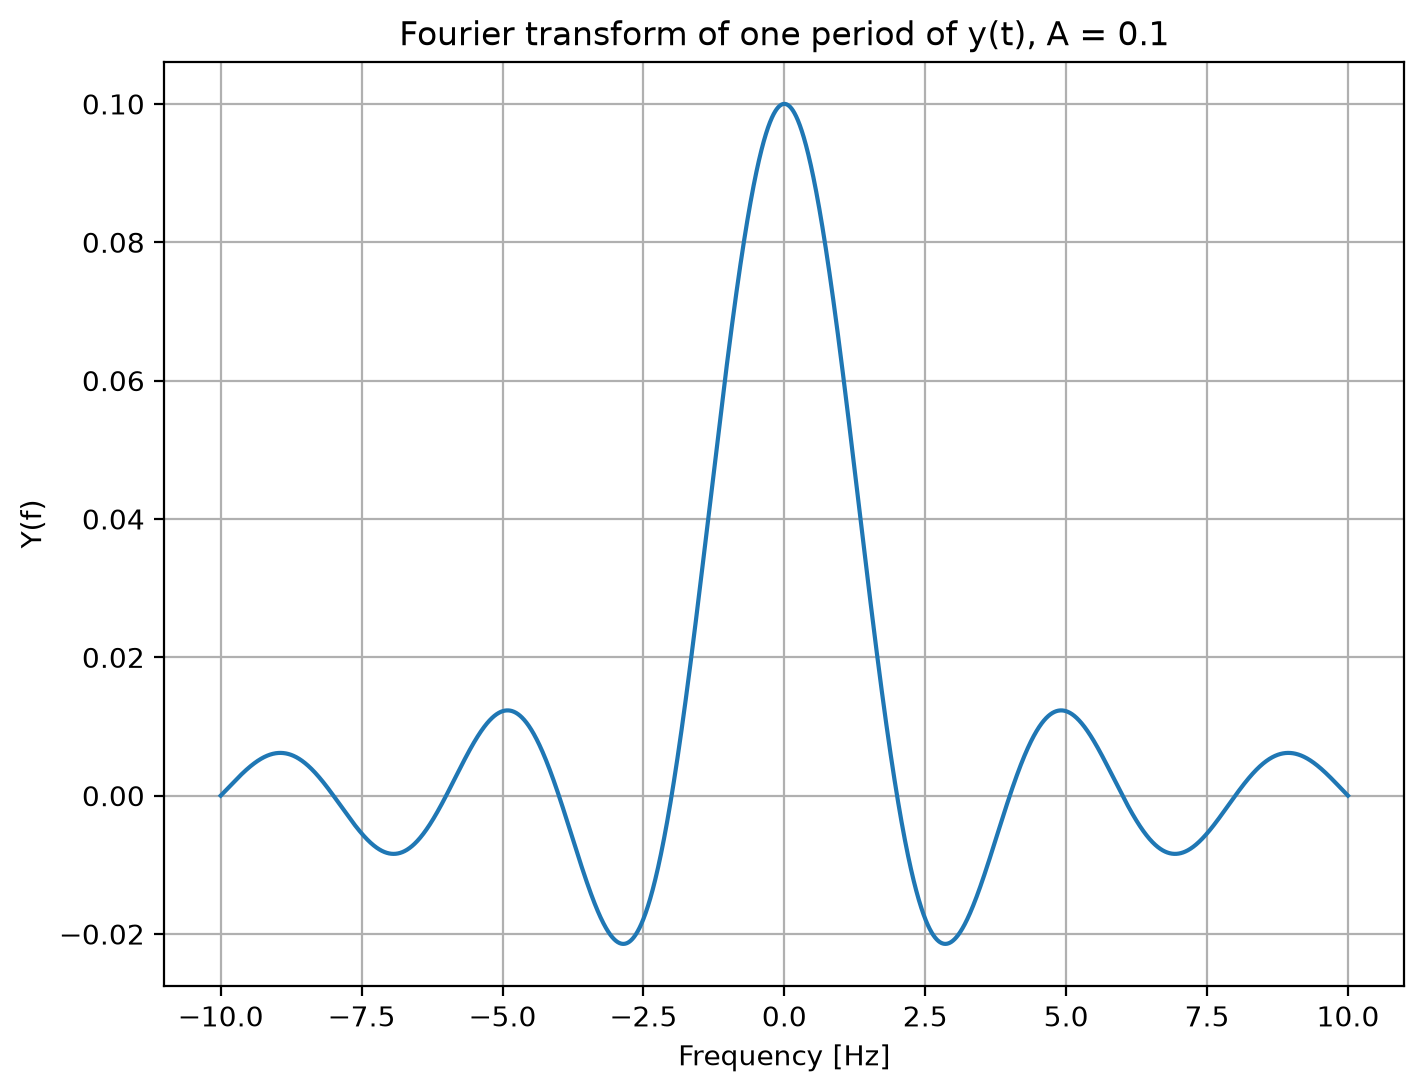

In [45]:
def fourier_transform_y(f, A):
    t1 = arccos(A) / (2 * pi)
    t2 = arccos(-A) / (2 * pi)
    return (
        2 * A * (t1 * sinc(2 * t1 * f) + t2 * sinc(2 * t2 * f))
        + t2 * (sinc(2 * t2 * (f + 1)) + sinc(2 * t2 * (f - 1)))
        - t1 * (sinc(2 * t1 * (f + 1)) + sinc(2 * t1 * (f - 1)))
    )


f = linspace(-10, 10, 4001)

for i, amplitude in enumerate([0.9, 0.5, 0.1]):
    Y = fourier_transform_y(f, amplitude)
    figure(2, figsize=(8, 6), dpi=200)
    plot(f, Y)
    xlabel("Frequency [Hz]")
    ylabel("Y(f)")
    title(f"Fourier transform of one period of y(t), A = {amplitude}")
    grid(True)
    show()

## Ejercicio 8 (b)

Y_S[-10] =  0.000000
Y_S[ -9] = -0.001476
Y_S[ -8] = -0.000000
Y_S[ -7] = -0.005754
Y_S[ -6] =  0.000000
Y_S[ -5] = -0.011009
Y_S[ -4] =  0.000000
Y_S[ -3] = -0.015817
Y_S[ -2] =  0.000000
Y_S[ -1] =  0.481307
Y_S[  0] =  0.900000
Y_S[  1] =  0.481307
Y_S[  2] =  0.000000
Y_S[  3] = -0.015817
Y_S[  4] =  0.000000
Y_S[  5] = -0.011009
Y_S[  6] =  0.000000
Y_S[  7] = -0.005754
Y_S[  8] = -0.000000
Y_S[  9] = -0.001476
Y_S[ 10] =  0.000000


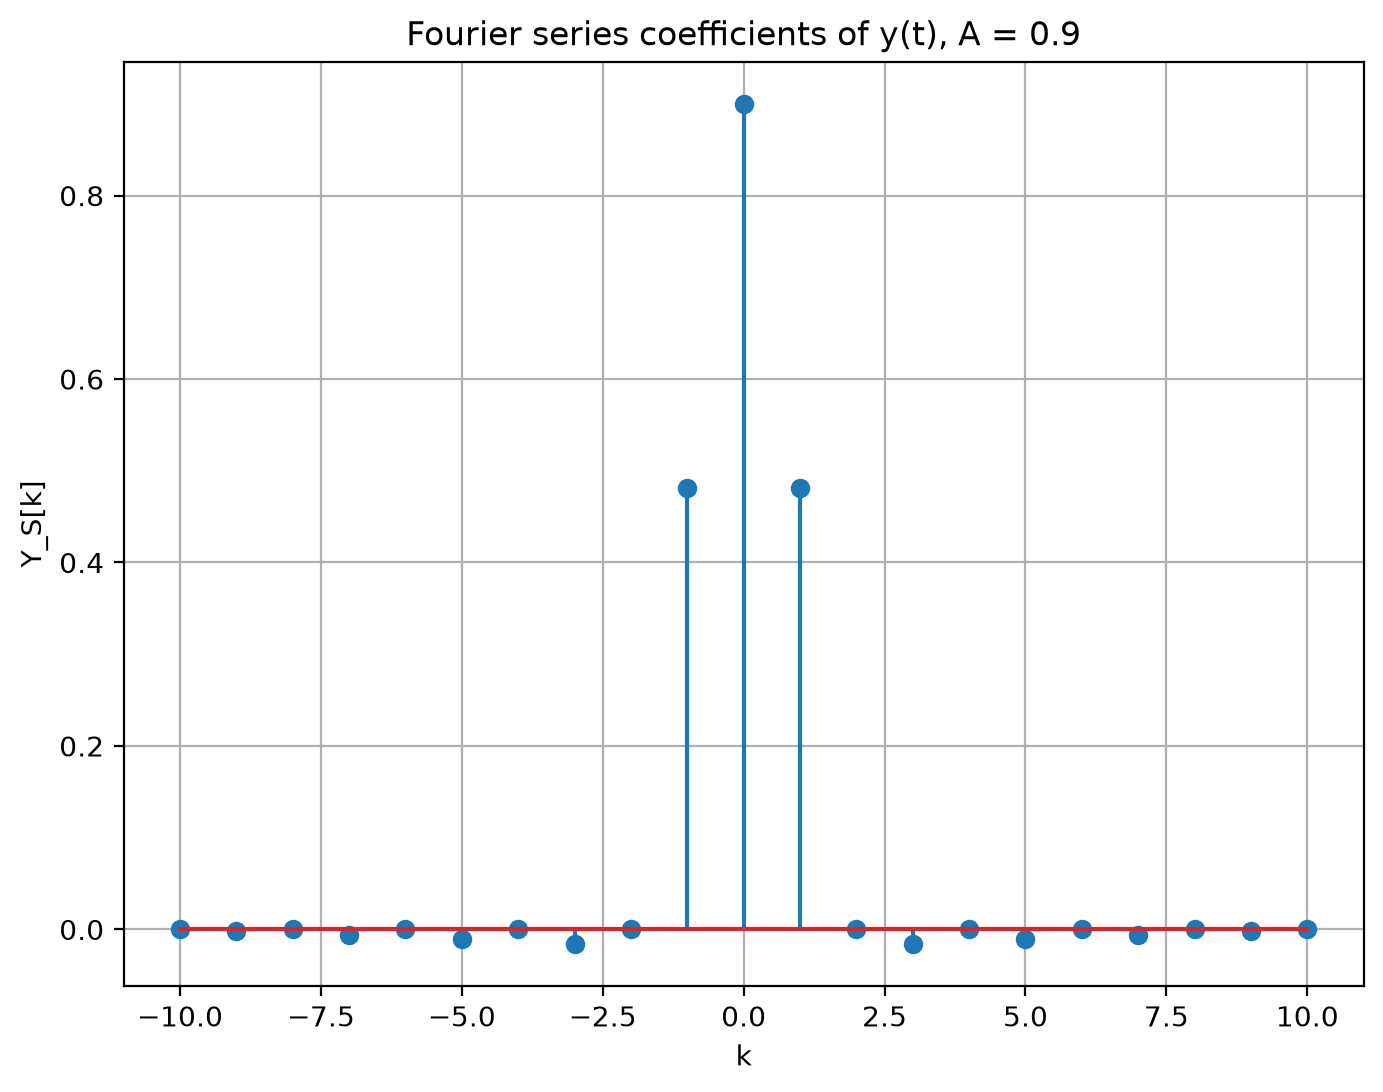

In [50]:
k_values = arange(-10, 10 + 1)
A = 0.9
Y_S = fourier_transform_y(k_values, A)

for k, coefficient in zip(k_values, Y_S):
    print(f"Y_S[{k:3d}] = {coefficient: .6f}")

figure(3, figsize=(8, 6), dpi=200)
stem(k_values, Y_S)
xlabel("k")
ylabel("Y_S[k]")
title(f"Fourier series coefficients of y(t), A = {A}")
grid(True)
show()

## Ejercicio 8 (c)

En este caso se observa que a medida el nivel de clipping A de la señal decrece ocurre mayor distorsión, lo que implica la aparición de armónicos de mayor amplitud. Cuando A tiende a 1 la señal se aproxima al coseno puro, por lo que en ese caso desaparecerían los armónicos y solamente sobreviviría la fundamental.

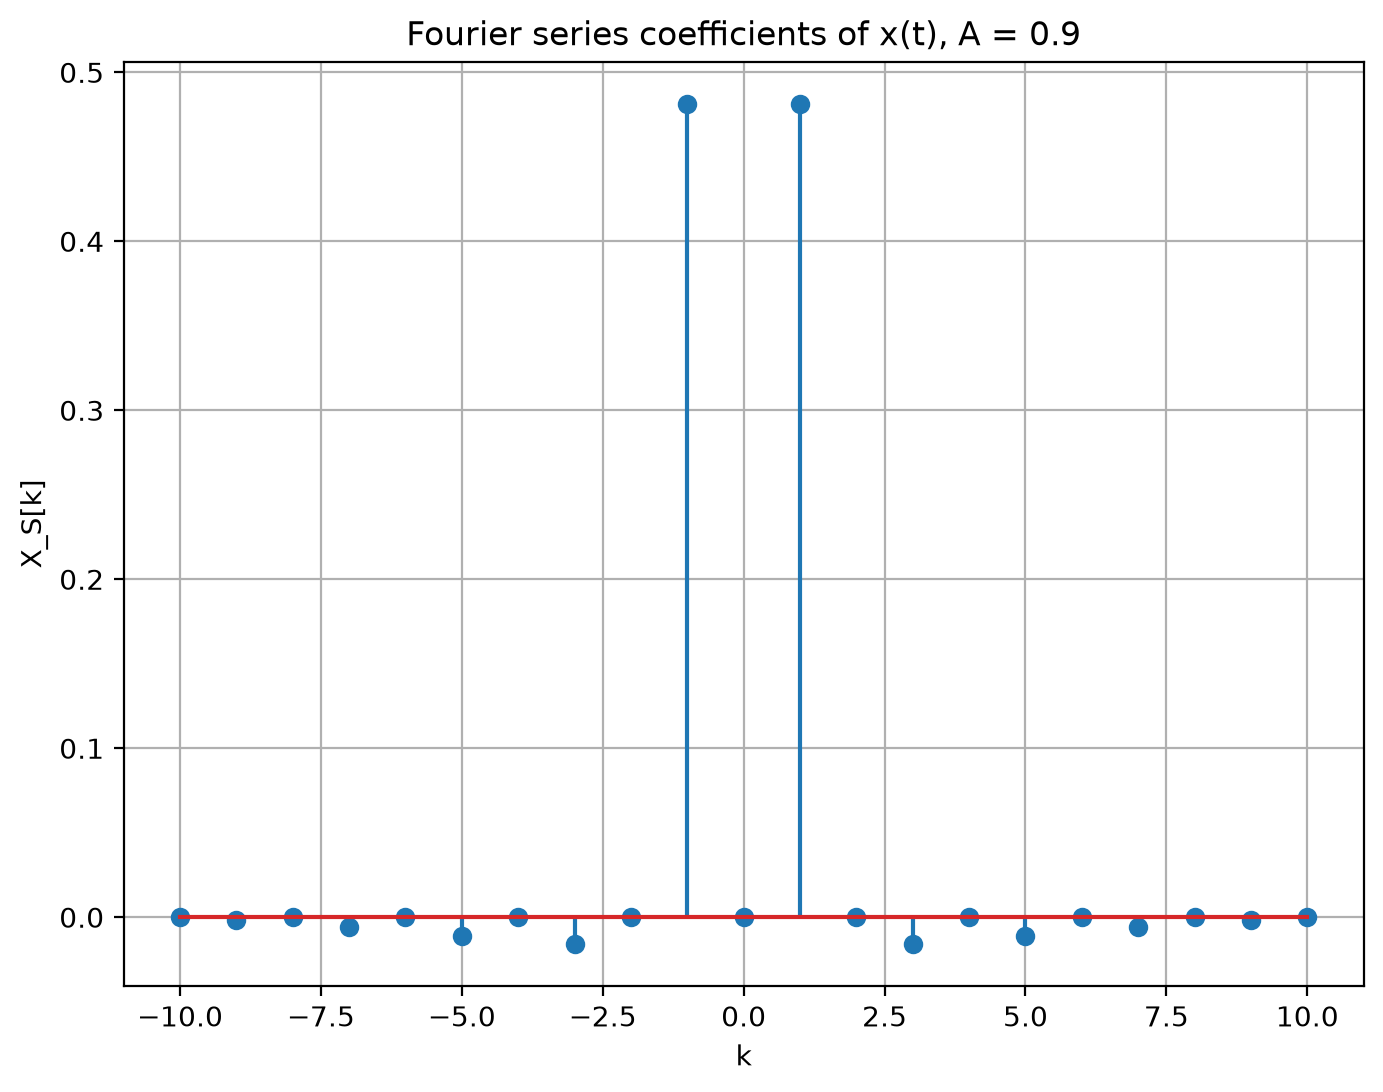

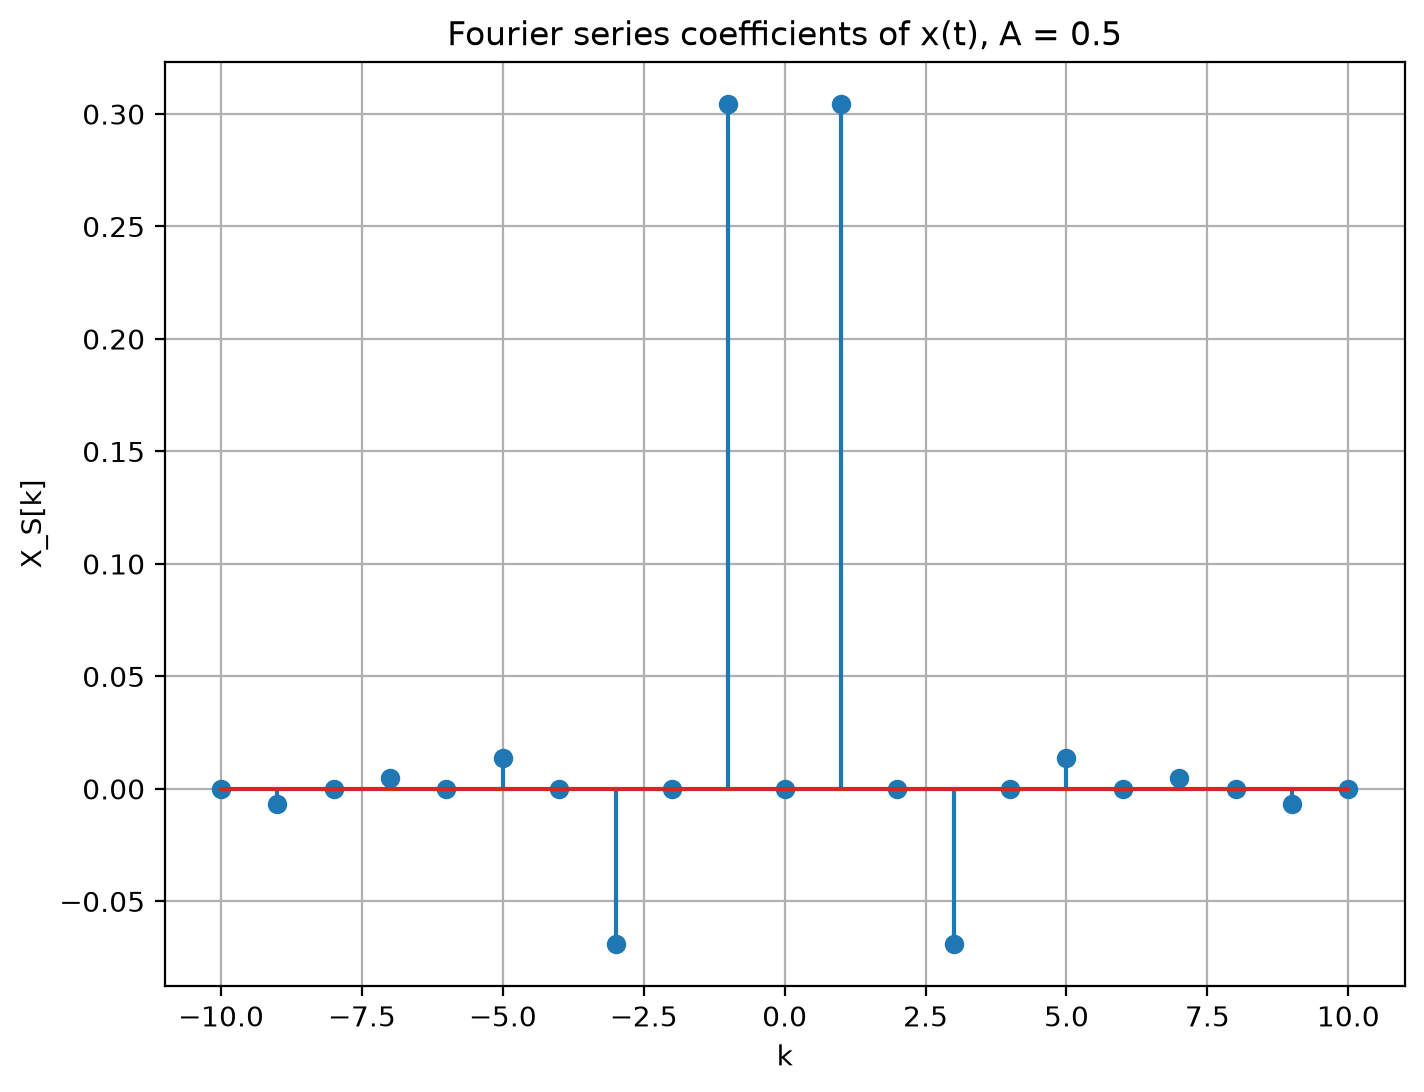

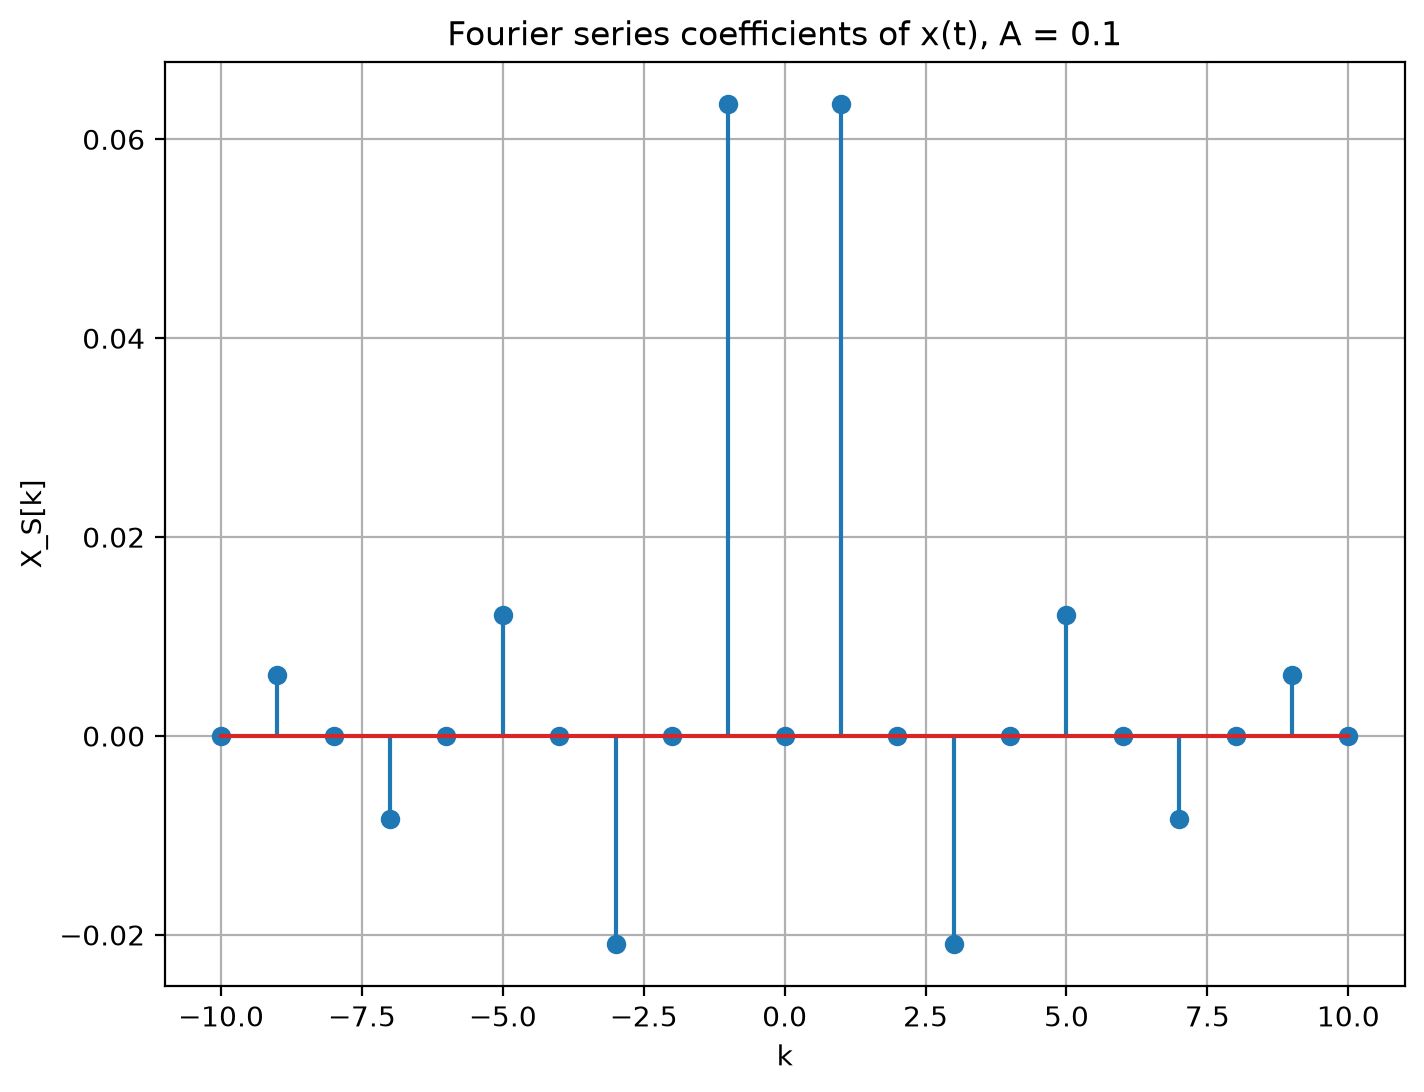

In [51]:
def fourier_series_x(k, A):
    """Fourier series coefficients of x(t) from those of y(t) = x(t) + A."""
    Y_S = fourier_transform_y(k, A)
    return where(k == 0, Y_S - A, Y_S)


for i, amplitude in enumerate([0.9, 0.5, 0.1]):
    X_S = fourier_series_x(k_values, amplitude)

    figure(4 + i, figsize=(8, 6), dpi=200)
    stem(k_values, X_S)
    xlabel("k")
    ylabel("X_S[k]")
    title(f"Fourier series coefficients of x(t), A = {amplitude}")
    grid(True)
    show()

## Ejercicio 8 (d)

En este caso se confirma lo que se estableció previamente en cuanto al aumento del nivel de distorsión (crecimiento de la potencia en los armónicos con respecto a la fundamental) a medida que el nivel de clipping A decrece.

A = 0.9
|X_S[ 2]|^2 / |X_S[1]|^2 = 3.325494e-33
|X_S[ 3]|^2 / |X_S[1]|^2 = 1.079989e-03
|X_S[ 4]|^2 / |X_S[1]|^2 = 3.325494e-33
|X_S[ 5]|^2 / |X_S[1]|^2 = 5.231639e-04
|X_S[ 6]|^2 / |X_S[1]|^2 = 1.875787e-32
|X_S[ 7]|^2 / |X_S[1]|^2 = 1.429145e-04
|X_S[ 8]|^2 / |X_S[1]|^2 = 1.052207e-33
|X_S[ 9]|^2 / |X_S[1]|^2 = 9.403173e-06
|X_S[10]|^2 / |X_S[1]|^2 = 5.196085e-33


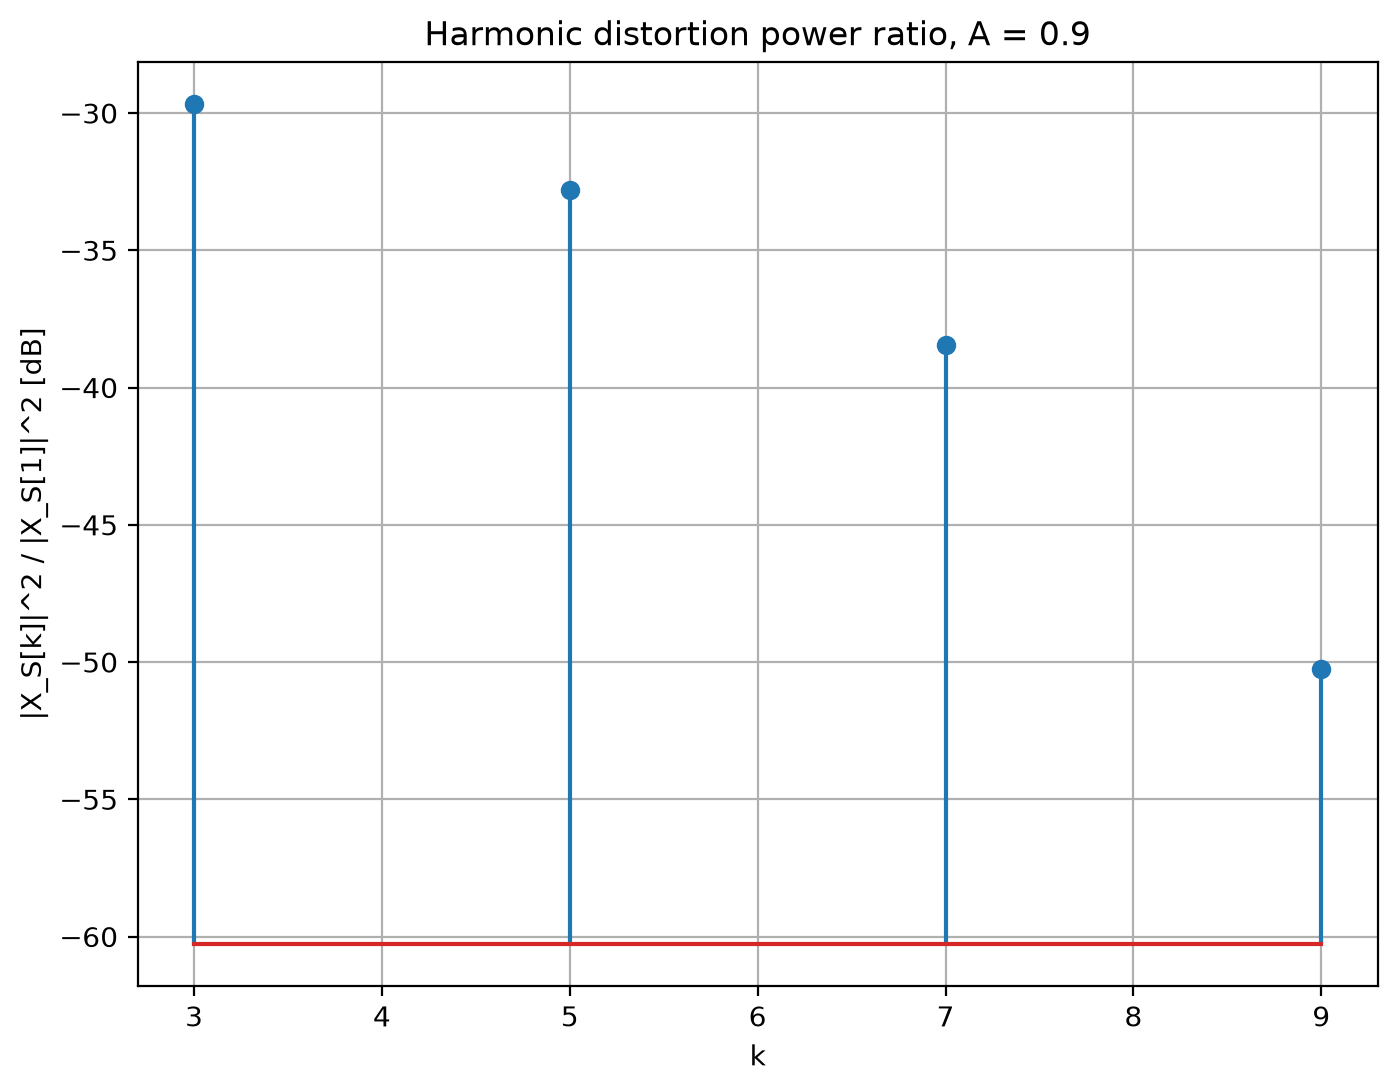

A = 0.5
|X_S[ 2]|^2 / |X_S[1]|^2 = 7.477761e-32
|X_S[ 3]|^2 / |X_S[1]|^2 = 5.122360e-02
|X_S[ 4]|^2 / |X_S[1]|^2 = 9.464041e-32
|X_S[ 5]|^2 / |X_S[1]|^2 = 2.048944e-03
|X_S[ 6]|^2 / |X_S[1]|^2 = 6.001033e-32
|X_S[ 7]|^2 / |X_S[1]|^2 = 2.613449e-04
|X_S[ 8]|^2 / |X_S[1]|^2 = 1.869440e-32
|X_S[ 9]|^2 / |X_S[1]|^2 = 5.122360e-04
|X_S[10]|^2 / |X_S[1]|^2 = 2.077156e-33


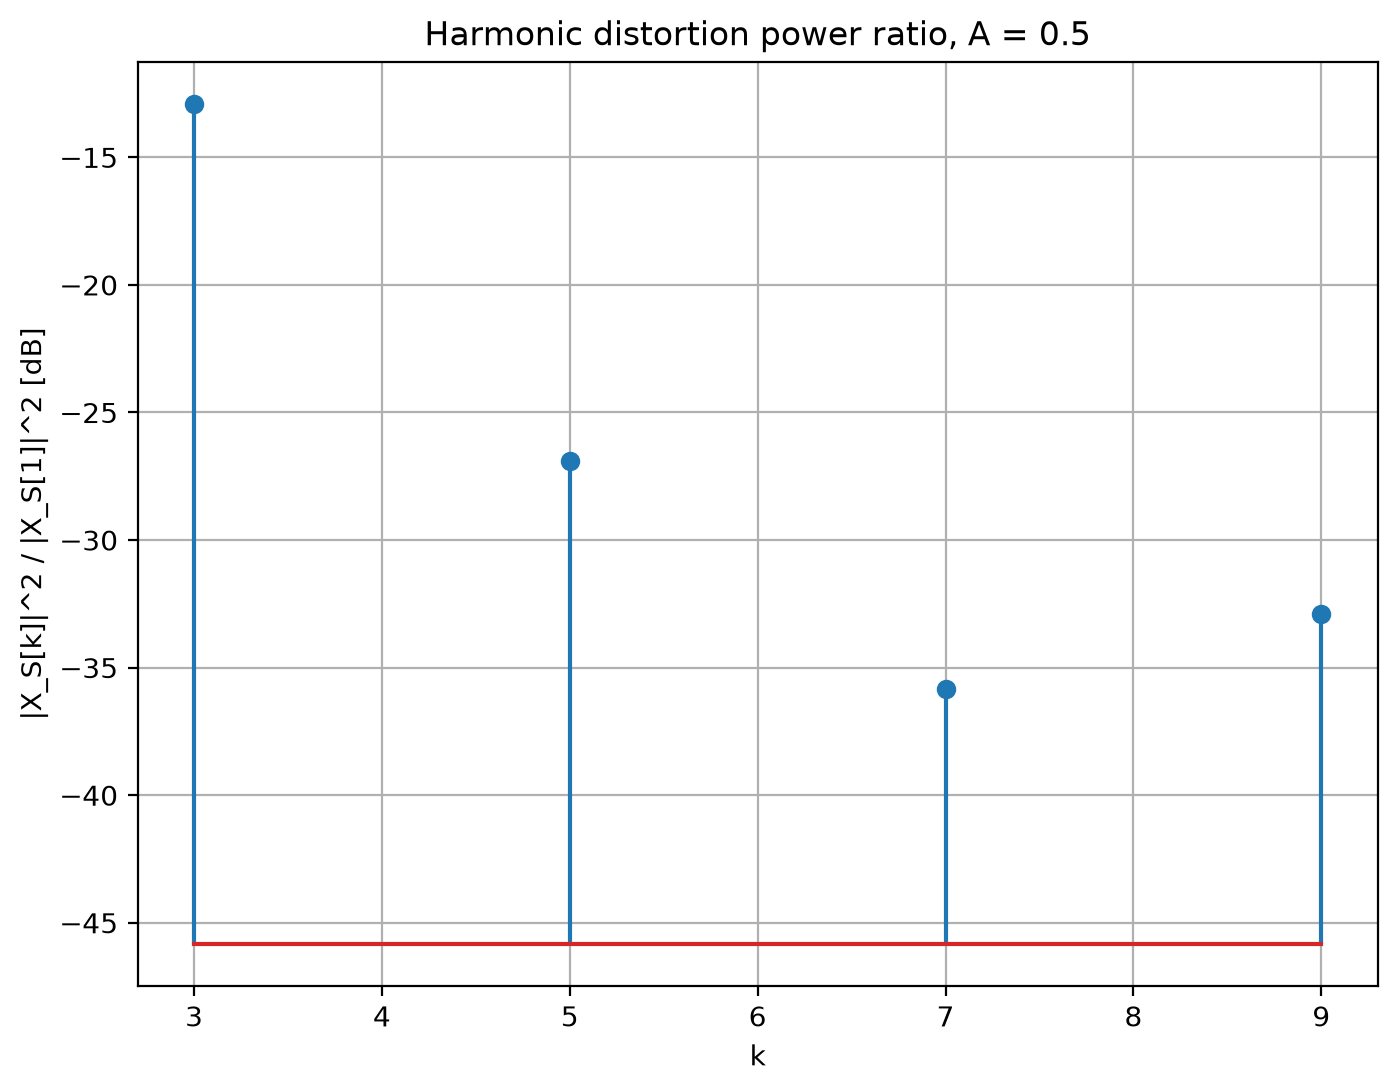

A = 0.1
|X_S[ 2]|^2 / |X_S[1]|^2 = 4.767945e-32
|X_S[ 3]|^2 / |X_S[1]|^2 = 1.081718e-01
|X_S[ 4]|^2 / |X_S[1]|^2 = 2.413772e-31
|X_S[ 5]|^2 / |X_S[1]|^2 = 3.689265e-02
|X_S[ 6]|^2 / |X_S[1]|^2 = 2.979966e-31
|X_S[ 7]|^2 / |X_S[1]|^2 = 1.733717e-02
|X_S[ 8]|^2 / |X_S[1]|^2 = 4.291151e-31
|X_S[ 9]|^2 / |X_S[1]|^2 = 9.378252e-03
|X_S[10]|^2 / |X_S[1]|^2 = 9.126146e-33


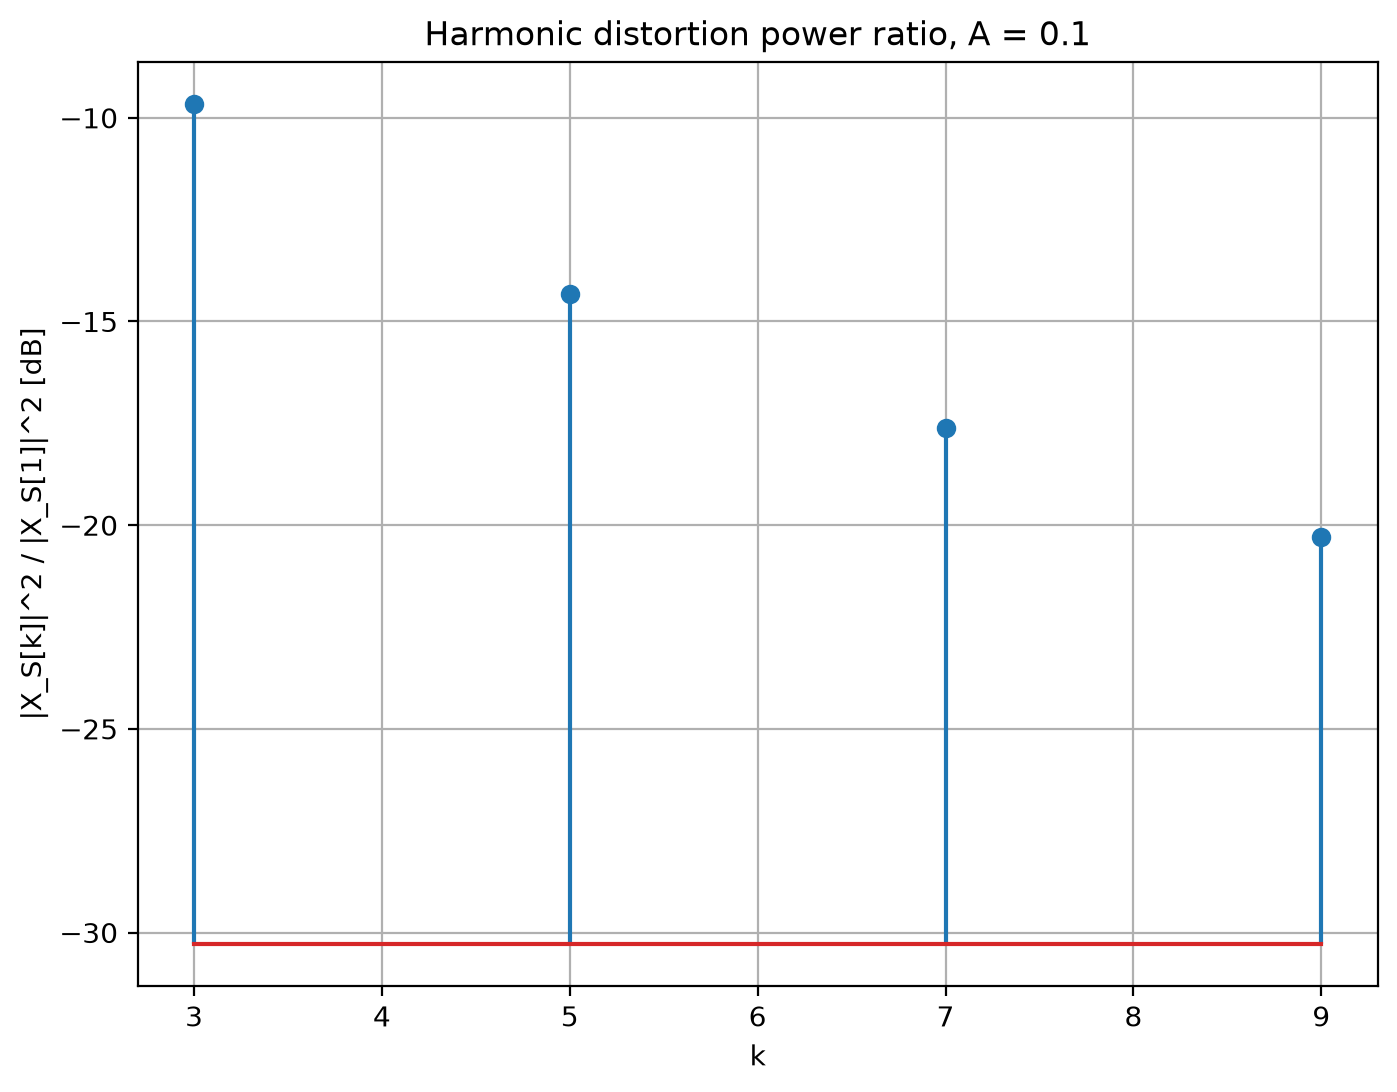

In [52]:
harmonics = arange(2, 11)
odd_harmonics = harmonics[harmonics % 2 == 1]

for i, amplitude in enumerate([0.9, 0.5, 0.1]):
    fundamental = fourier_series_x(1, amplitude)
    distortion_ratio = abs(fourier_series_x(harmonics, amplitude)) ** 2 / fundamental**2

    print(f"A = {amplitude}")
    for k, ratio in zip(harmonics, distortion_ratio):
        print(f"|X_S[{k:2d}]|^2 / |X_S[1]|^2 = {ratio:.6e}")

    odd_ratio_db = 10 * log10(distortion_ratio[harmonics % 2 == 1])

    figure(7 + i, figsize=(8, 6), dpi=200)
    stem(odd_harmonics, odd_ratio_db, bottom=odd_ratio_db.min() - 10)
    xlabel("k")
    ylabel("|X_S[k]|^2 / |X_S[1]|^2 [dB]")
    title(f"Harmonic distortion power ratio, A = {amplitude}")
    grid(True)
    show()

## Ejercicio 8 (e)

En este caso se observa cómo la serie de Fourier de la señal $x(t)$ se aproxima a la señal original a medida que el número de armónicos que se agregan a la suma se incrementa.

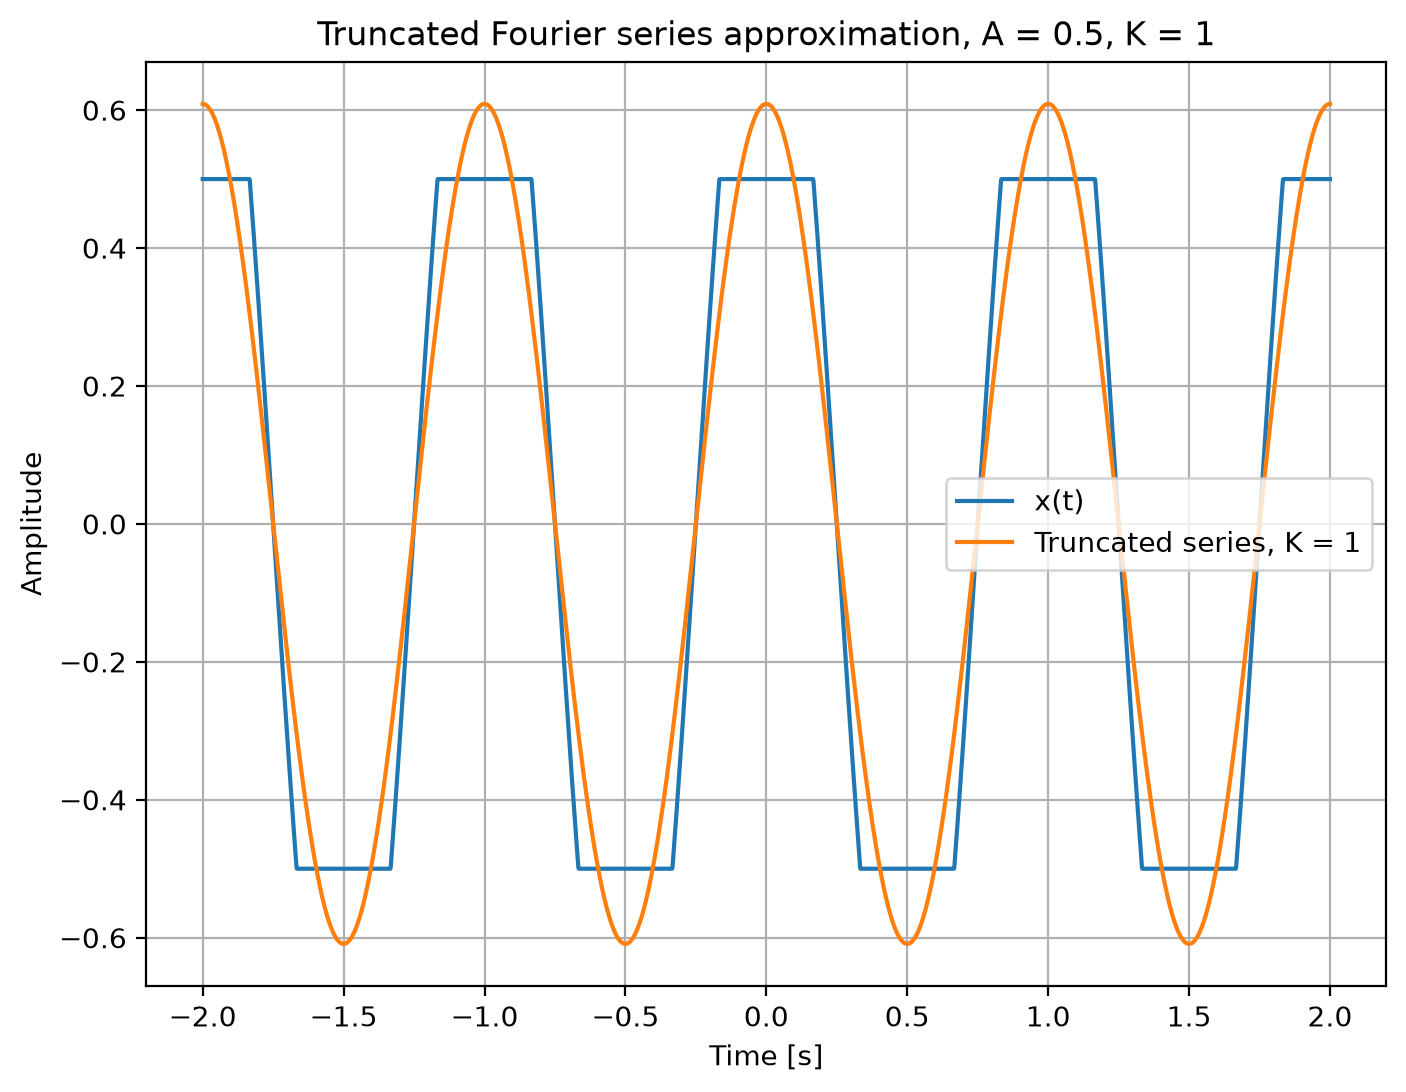

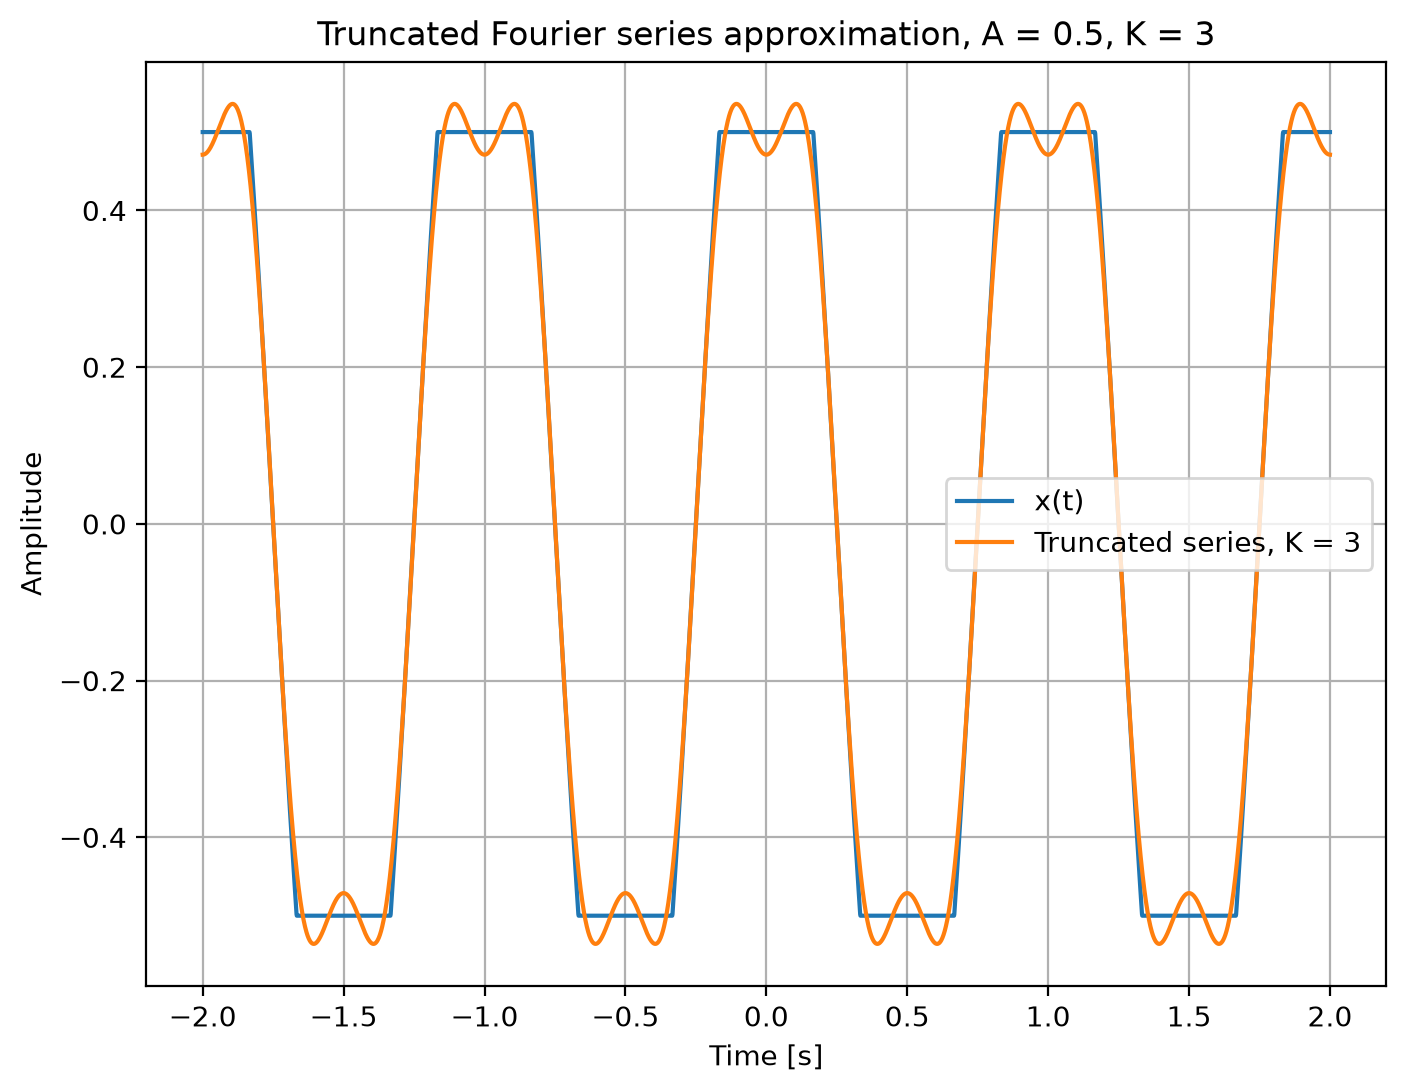

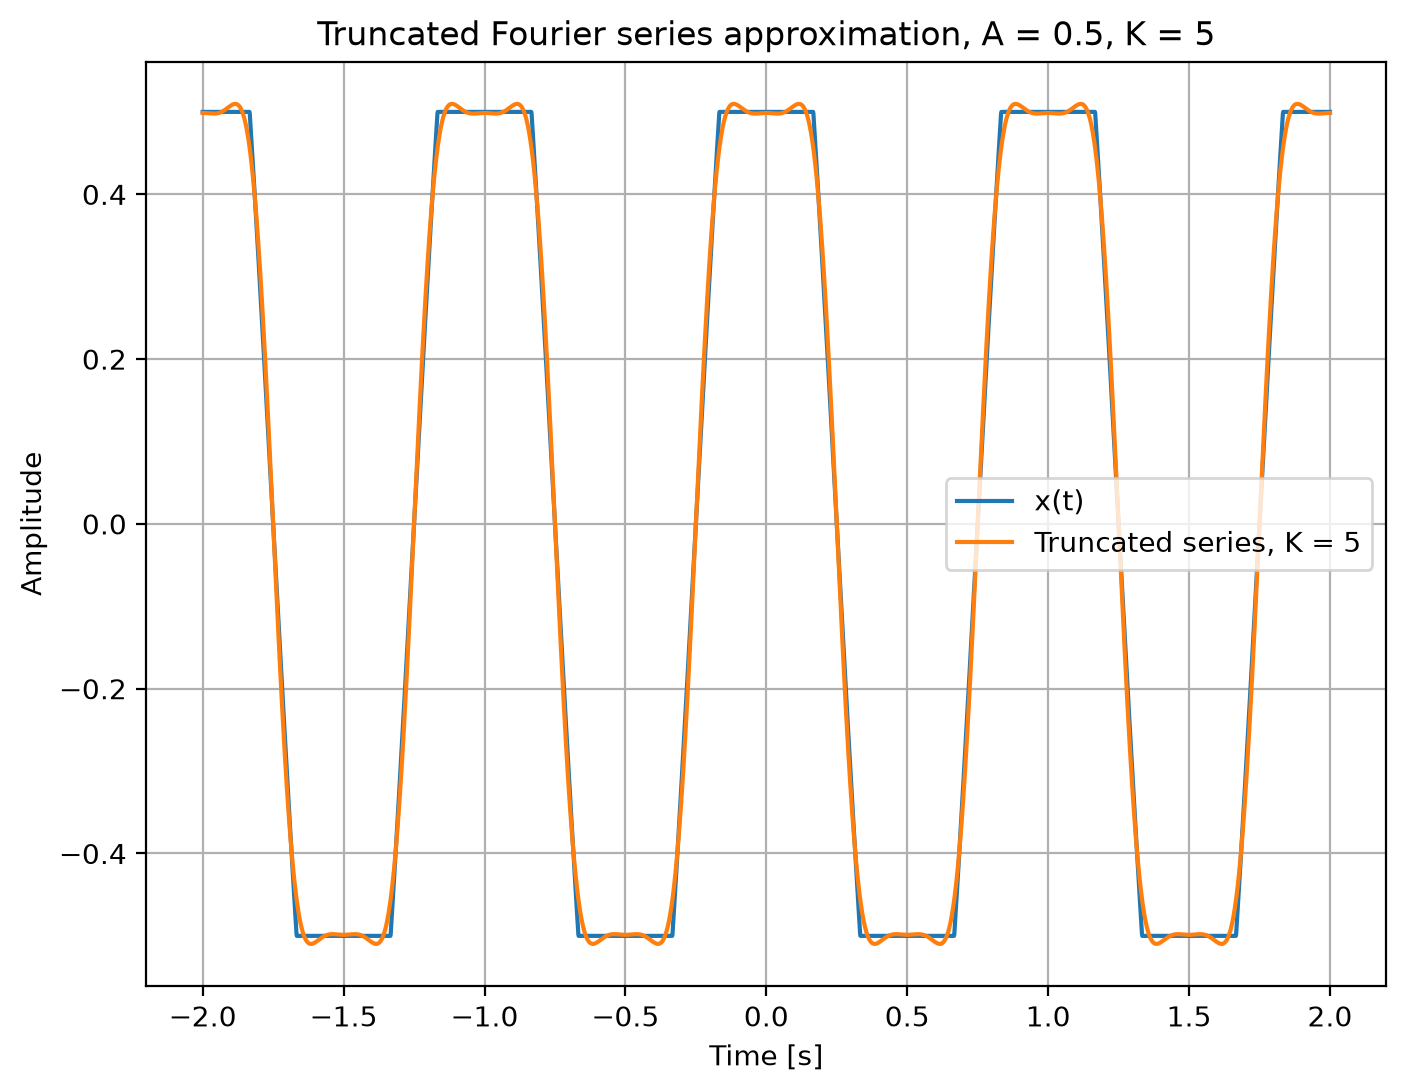

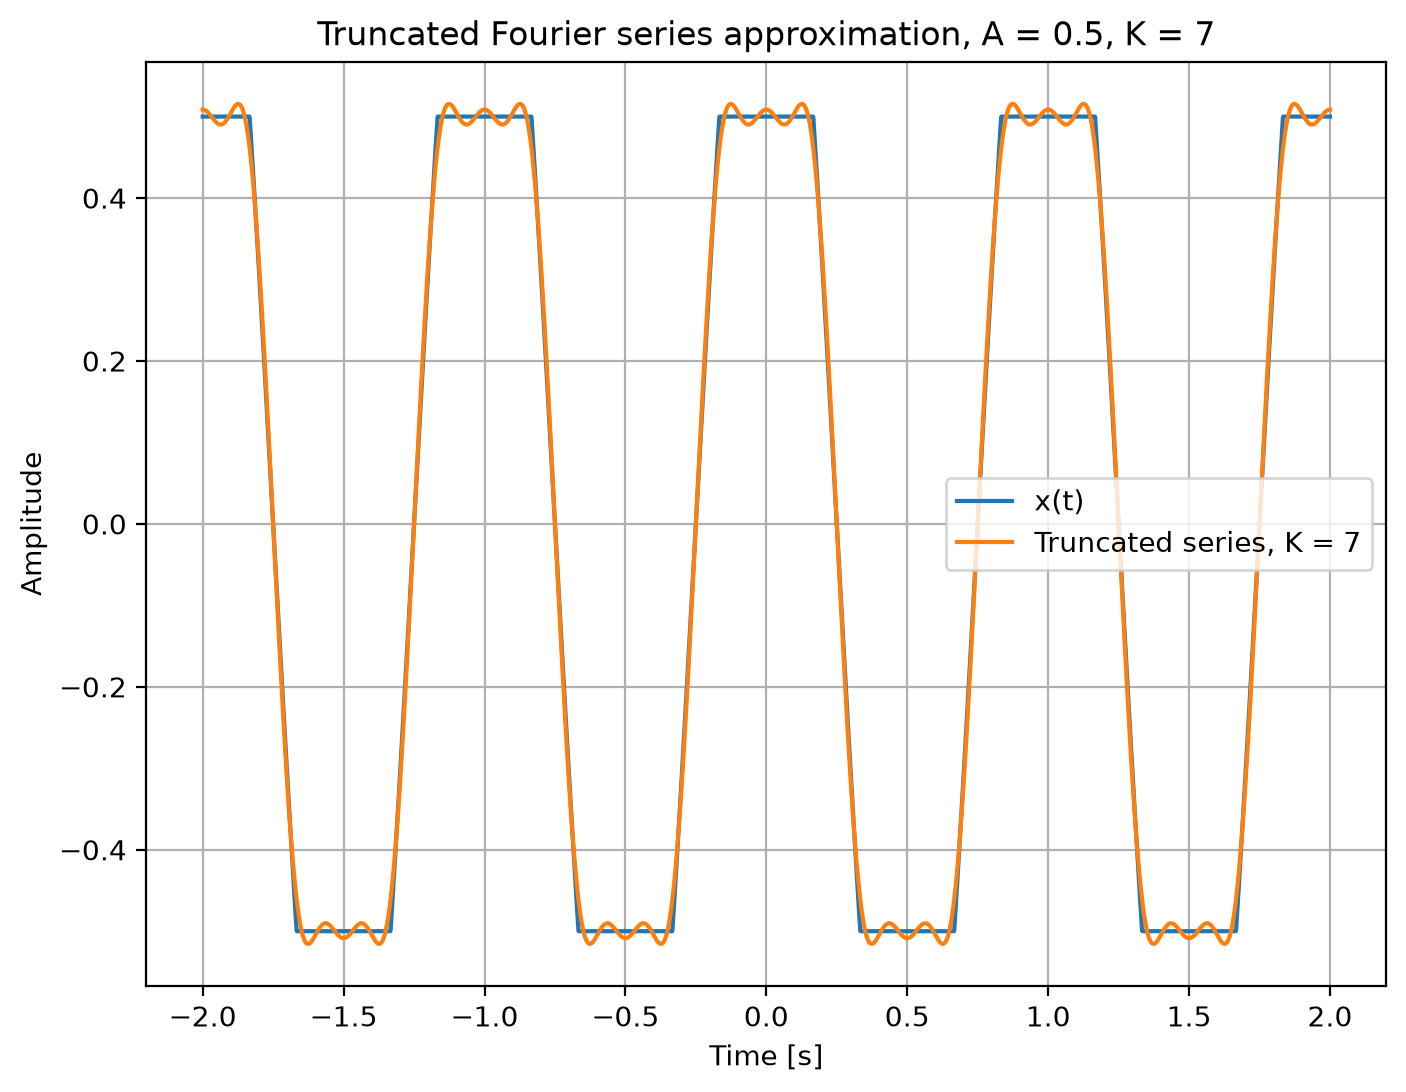

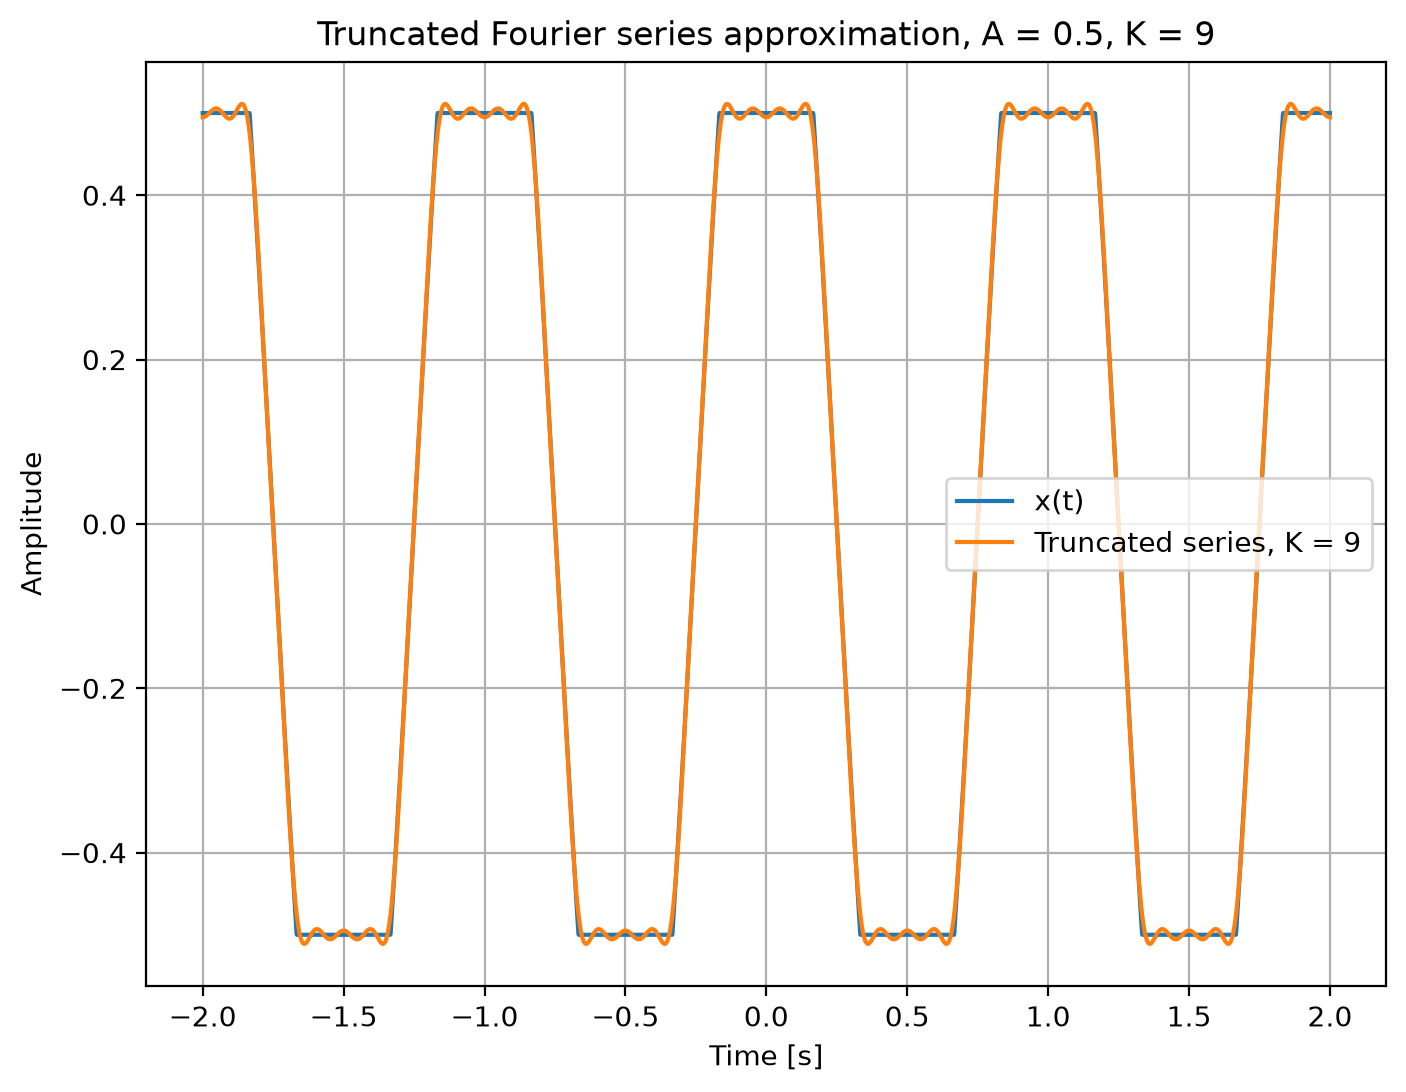

In [53]:
A_e = 0.5
t_e = linspace(-2, 2, 4001)
x_e = clip(cos(2 * pi * t_e), -A_e, A_e)

x_hat = zeros(t_e.size)
for k in range(1, 10):
    x_hat += 2 * fourier_series_x(k, A_e) * cos(2 * pi * k * t_e)
    if k % 2 == 1:
        figure(10 + k // 2, figsize=(8, 6), dpi=200)
        plot(t_e, x_e, label="x(t)")
        plot(t_e, x_hat, label=f"Truncated series, K = {k}")
        xlabel("Time [s]")
        ylabel("Amplitude")
        title(f"Truncated Fourier series approximation, A = {A_e}, K = {k}")
        legend()
        grid(True)
        show()